# IT25101220 - Decision Tree Classifier Implementation
## Course: IT2011 - Artificial Intelligence and Machine Learning
### Project: Predicting Adult Income Level Using Machine Learning
**Student ID:** IT25101220  
**Model:** `DecisionTreeClassifier` (Supervised Binary Classification)  
**Target:** `income` (`0: <=50K`, `1: >50K`)

---

### Workflow Overview:
1. **Imports & Configuration:** Environment setup, dynamic repository root discovery, plotting aesthetics.
2. **Data Loading:** Ingestion of partitioned training and testing datasets created via deterministic group cleaning.
3. **Dataset Verification:** Validation of shapes, missing values, and target class distributions.
4. **Predictor & Target Segregation:** Separation into feature matrices ($X$) and target vectors ($y$).
5. **Preprocessing Pipeline:** Encapsulation via `ColumnTransformer` (categorical mode imputation + One-Hot Encoding; numerical median imputation).
6. **Baseline Model Training:** Unconstrained `DecisionTreeClassifier(random_state=42)` fitted inside an end-to-end `Pipeline`.
7. **Baseline Model Evaluation:** Out-of-sample performance metrics on untouched test partition.
8. **Overfitting Analysis:** Generalization gap quantification between training and testing accuracy.
9. **Stratified Cross-Validation:** 5-fold cross-validation establishing robust baseline metrics.
10. **Hyperparameter Grid Setup:** Search space definition across pruning parameters (`criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `class_weight`).
11. **GridSearchCV Execution:** 5-fold stratified hyperparameter tuning optimizing binary F1 score.
12. **Optimal Hyperparameters:** Extraction and inspection of the best estimator and parameter set.
13. **Tuned Model Evaluation:** Out-of-sample testing on the holdout test set and overfitting reduction check.
14. **Baseline vs. Tuned Comparison:** Comprehensive comparison table and comparative bar chart.
15. **Confusion Matrix Visualizations:** Heatmaps for baseline and tuned model predictions.
16. **ROC Curves:** Comparative Receiver Operating Characteristic curves with AUC scores.
17. **Feature Importance Analysis:** Extraction and visualization of top Gini importance features.
18. **Tree Structure Visualization:** Architectural visualization of top 3 split levels.
19. **Final Summary & JSON Export:** Summary report and standardized model metrics export to `results/model_results/IT25101220.json`.


### 1. Imports and Configuration
Import all required libraries for modeling, pipelines, metrics, and visualization. Dynamically establish the project root path to ensure complete reproducibility regardless of execution working directory.


In [1]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tree, preprocessing, and pipeline modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
)

# Robust project root discovery
current_path = Path.cwd().resolve()
for candidate in [current_path, current_path.parent, current_path.parent.parent]:
    if (candidate / "data" / "raw" / "adult.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path(".").resolve()

# Normalize the working directory and import path for repository-relative shared utilities.
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.common import save_member_result

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult.csv"
MODEL_PLOTS_DIR = PROJECT_ROOT / "results" / "eda_visualizations" / "models"
MODEL_RESULTS_DIR = PROJECT_ROOT / "results" / "model_results"

MODEL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Graphics aesthetic setup
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

print("Project Root: .")
print("Plot Directory:", MODEL_PLOTS_DIR.relative_to(PROJECT_ROOT))
print("Results Directory:", MODEL_RESULTS_DIR.relative_to(PROJECT_ROOT))
print("Libraries imported successfully.")


Project Root: .
Plot Directory: results\eda_visualizations\models
Results Directory: results\model_results
Libraries imported successfully.


### 2. Load Final Group-Prepared Data
Load the raw Adult Income dataset and execute common deterministic cleaning aligned with group contributions:
1. Strip leading/trailing whitespace across all string columns.
2. Convert `'?'` missing-value markers to `np.nan` (IT25102064).
3. Drop 24 exact duplicate records (IT25101220).
4. Drop redundant categorical `'education'` feature, retaining ordinal `'education.num'` (IT25300115).
5. Map binary target `'income'` to integers (`<=50K` -> 0, `>50K` -> 1).
6. Partition via 80/20 Stratified Split (`random_state=42`, `stratify=y`). Missing values intentionally remain unhandled for leak-free pipeline imputation.


In [2]:
# 1. Load raw Adult census dataset
assert RAW_DATA_PATH.exists(), f"Error: Raw dataset not found at {RAW_DATA_PATH}"
df_raw = pd.read_csv(RAW_DATA_PATH)
df = df_raw.copy()

# 2. Strip string whitespace & convert '?' to NaN (IT25102064)
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()
df.replace('?', np.nan, inplace=True)

# 3. Drop exact duplicates (24 rows) (IT25101220)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# 4. Drop redundant 'education' feature, retaining 'education.num' (IT25300115)
df.drop(columns=['education'], inplace=True)

# 5. Map binary target 'income' (<=50K -> 0, >50K -> 1)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# 6. Separate predictors and target
X = df.drop(columns=['income'])
y = df['income']

# 7. Stratified Train/Test Split (80/20, seed=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"X_test shape:  {X_test.shape[0]:,} rows, {X_test.shape[1]} columns")
print(f"y_train shape: {y_train.shape[0]:,} rows")
print(f"y_test shape:  {y_test.shape[0]:,} rows")


X_train shape: 26,029 rows, 13 columns
X_test shape:  6,508 rows, 13 columns
y_train shape: 26,029 rows
y_test shape:  6,508 rows


### 3. Verify Dataset
Inspect the first five training samples, quantify missing values across partitions, and examine class distribution balance.


In [3]:
print("--- First 5 Rows of Training Predictors ---")
display(X_train.head())

print("\n--- Missing Values Verification ---")
train_missing = X_train.isna().sum()
test_missing = X_test.isna().sum()
print(f"Total training missing values: {train_missing.sum():,}")
print(f"Total testing missing values:  {test_missing.sum():,}")
print("\nMissing values per column in X_train:")
print(train_missing[train_missing > 0])
print("\nMissing values per column in X_test:")
print(test_missing[test_missing > 0])

print("\n--- Target Variable Distribution in Training Set ---")
train_counts = y_train.value_counts()
train_pcts = y_train.value_counts(normalize=True) * 100

target_dist_df = pd.DataFrame({
    "Class (income)": ["0 (<=50K)", "1 (>50K)"],
    "Count": [train_counts.get(0, 0), train_counts.get(1, 0)],
    "Percentage (%)": [train_pcts.get(0, 0), train_pcts.get(1, 0)]
})
display(target_dist_df)


--- First 5 Rows of Training Predictors ---


,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
25252,21,NaN,140012,10,Never-married,NaN,Own-child,White,Male,0,0,20,United-States
3349,41,Private,433989,11,Married-civ-spouse,Sales,Husband,White,Male,4386,0,60,United-States
4584,24,Private,241951,9,Never-married,Handlers-cleaners,Unmarried,Black,Female,0,0,40,United-States
7003,59,Private,99131,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,0,18,United-States
882,35,Private,267866,9,Married-civ-spouse,Sales,Husband,Asian-Pac-Islander,Male,0,1887,50,Iran



--- Missing Values Verification ---
Total training missing values: 3,419
Total testing missing values:  842

Missing values per column in X_train:
workclass         1472
occupation        1478
native.country     469
dtype: int64

Missing values per column in X_test:
workclass         364
occupation        365
native.country    113
dtype: int64

--- Target Variable Distribution in Training Set ---


,Class (income),Count,Percentage (%)
0,0 (<=50K),19758,75.907641
1,1 (>50K),6271,24.092359


### 4. Separate Features and Target
Identify numerical and categorical column names and validate against the expected schema.


In [4]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

EXPECTED_NUMERICAL = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
EXPECTED_CATEGORICAL = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

assert set(numerical_features) == set(EXPECTED_NUMERICAL), "Numerical feature schema mismatch!"
assert set(categorical_features) == set(EXPECTED_CATEGORICAL), "Categorical feature schema mismatch!"

print(f"Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")
print("Feature identification and schema validation PASSED.")


Numerical Features (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical Features (7): ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Feature identification and schema validation PASSED.


### 5. Preprocessing Configuration
Assemble a Scikit-Learn `ColumnTransformer`. 
- **Numerical Pipeline:** Uses `SimpleImputer(strategy="median")` as a defensive step (numerical features contain zero nulls). Feature scaling (`StandardScaler`) is **intentionally omitted** because Decision Tree splits are invariant to monotonic transformations.
- **Categorical Pipeline:** Employs `SimpleImputer(strategy="most_frequent")` followed by `OneHotEncoder(handle_unknown="ignore")`.
- **Leakage Prevention:** All imputation and encoding statistics are strictly learned from training data during pipeline fitting.


In [5]:
# Numerical Pipeline: Median imputation (defensive); No scaling required for Decision Trees
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical Pipeline: Mode imputation and One-Hot Encoding
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combined ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing ColumnTransformer successfully assembled.")


Preprocessing ColumnTransformer successfully assembled.


### 6. Baseline Decision Tree Model Training
Instantiate an unpruned baseline `DecisionTreeClassifier(random_state=42)` encapsulated within an end-to-end `Pipeline`. Train strictly on `X_train`.


In [6]:
# Initialize unconstrained baseline Decision Tree
baseline_dt = DecisionTreeClassifier(random_state=42)

# Assemble baseline pipeline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", baseline_dt)
    ]
)

# Fit pipeline strictly on training data
baseline_pipeline.fit(X_train, y_train)
print("Baseline Decision Tree training completed successfully.")


Baseline Decision Tree training completed successfully.


### 7. Baseline Model Evaluation
Evaluate the baseline model against the untouched test partition (`X_test`, `y_test`). Compute Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [7]:
# Predict on test partition
y_pred_base = baseline_pipeline.predict(X_test)
y_prob_base = baseline_pipeline.predict_proba(X_test)[:, 1]

# Calculate metrics
baseline_accuracy = float(accuracy_score(y_test, y_pred_base))
baseline_precision = float(precision_score(y_test, y_pred_base))
baseline_recall = float(recall_score(y_test, y_pred_base))
baseline_f1 = float(f1_score(y_test, y_pred_base))
baseline_roc_auc = float(roc_auc_score(y_test, y_prob_base))

print("==========================================================")
print("             BASELINE DECISION TREE METRICS               ")
print("==========================================================")
print(f" - Accuracy:  {baseline_accuracy:.4f} ({baseline_accuracy * 100:.2f}%)")
print(f" - Precision: {baseline_precision:.4f} ({baseline_precision * 100:.2f}%)")
print(f" - Recall:    {baseline_recall:.4f} ({baseline_recall * 100:.2f}%)")
print(f" - F1 Score:  {baseline_f1:.4f} ({baseline_f1 * 100:.2f}%)")
print(f" - ROC-AUC:   {baseline_roc_auc:.4f}")
print("==========================================================\n")

print("--- Classification Report (Baseline Decision Tree) ---")
print(classification_report(y_test, y_pred_base, target_names=["<=50K (0)", ">50K (1)"]))


             BASELINE DECISION TREE METRICS               
 - Accuracy:  0.8078 (80.78%)
 - Precision: 0.5996 (59.96%)
 - Recall:    0.6084 (60.84%)
 - F1 Score:  0.6040 (60.40%)
 - ROC-AUC:   0.7397

--- Classification Report (Baseline Decision Tree) ---
              precision    recall  f1-score   support

   <=50K (0)       0.88      0.87      0.87      4940
    >50K (1)       0.60      0.61      0.60      1568

    accuracy                           0.81      6508
   macro avg       0.74      0.74      0.74      6508
weighted avg       0.81      0.81      0.81      6508



### 8. Overfitting & Generalization Gap Analysis
Compare training accuracy and testing accuracy on the baseline model to assess the degree of empirical overfitting.


In [8]:
baseline_train_acc = float(baseline_pipeline.score(X_train, y_train))
baseline_test_acc = float(baseline_pipeline.score(X_test, y_test))
baseline_gen_gap = float(baseline_train_acc - baseline_test_acc)

print("--- Training vs. Testing Accuracy (Baseline) ---")
print(f"Training Accuracy:  {baseline_train_acc:.4f} ({baseline_train_acc * 100:.2f}%)")
print(f"Testing Accuracy:   {baseline_test_acc:.4f} ({baseline_test_acc * 100:.2f}%)")
print(f"Generalization Gap: {baseline_gen_gap:.4f} ({baseline_gen_gap * 100:.2f}%)")
print("Conclusion: Unconstrained baseline exhibits severe overfitting (100% training accuracy vs. 80.78% testing accuracy).")


--- Training vs. Testing Accuracy (Baseline) ---
Training Accuracy:  1.0000 (100.00%)
Testing Accuracy:   0.8078 (80.78%)
Generalization Gap: 0.1922 (19.22%)
Conclusion: Unconstrained baseline exhibits severe overfitting (100% training accuracy vs. 80.78% testing accuracy).


### 9. Stratified Cross-Validation
Perform 5-fold stratified cross-validation on the baseline pipeline to establish variance across training folds.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print("Executing 5-Fold Stratified Cross-Validation on Baseline Pipeline...")
cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = []
for m in scoring_metrics:
    scores = cv_results[f"test_{m}"]
    cv_summary.append({
        "Metric": m.upper(),
        "Mean Score": f"{scores.mean():.4f}",
        "Std Dev (±)": f"{scores.std():.4f}",
        "Fold Scores": [f"{s:.4f}" for s in scores]
    })

cv_summary_df = pd.DataFrame(cv_summary)
print("\n==========================================================")
print("       5-FOLD STRATIFIED CROSS-VALIDATION RESULTS        ")
print("==========================================================")
display(cv_summary_df[["Metric", "Mean Score", "Std Dev (±)"]])


Executing 5-Fold Stratified Cross-Validation on Baseline Pipeline...



       5-FOLD STRATIFIED CROSS-VALIDATION RESULTS        


,Metric,Mean Score,Std Dev (±)
0,ACCURACY,0.8173,0.0041
1,PRECISION,0.6186,0.0076
2,RECALL,0.6302,0.0130
3,F1,0.6243,0.0098
4,ROC_AUC,0.7535,0.0070


### 10. Hyperparameter Grid Setup
Construct the hyperparameter grid exploring pre-pruning bounds (`max_depth`, `min_samples_split`, `min_samples_leaf`), split criteria (`gini`, `entropy`), and class weighting (`None`, `balanced`).


In [10]:
param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__class_weight": [None, "balanced"]
}

n_combos = (
    len(param_grid["classifier__criterion"]) *
    len(param_grid["classifier__max_depth"]) *
    len(param_grid["classifier__min_samples_split"]) *
    len(param_grid["classifier__min_samples_leaf"]) *
    len(param_grid["classifier__class_weight"])
)
print(f"Total parameter combinations: {n_combos}")
print(f"Total model fits (5-fold CV): {n_combos * 5:,}")


Total parameter combinations: 320
Total model fits (5-fold CV): 1,600


### 11. Hyperparameter Tuning with GridSearchCV
Execute exhaustive 5-fold cross-validated grid search optimizing on binary F1 score. Refit the optimal model on the entire training set.


In [11]:
grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

print("Starting GridSearchCV for Decision Tree Classifier...")
grid_search.fit(X_train, y_train)
print("GridSearchCV optimization completed successfully.")


Starting GridSearchCV for Decision Tree Classifier...
Fitting 5 folds for each of 320 candidates, totalling 1600 fits


GridSearchCV optimization completed successfully.


### 12. Optimal Hyperparameters Inspection
Inspect optimal hyperparameter settings identified by GridSearchCV and extract the best estimator.


In [12]:
print("--- Best Hyperparameters Identified by GridSearchCV ---")
for p, v in grid_search.best_params_.items():
    print(f" - {p}: {v}")

best_cv_f1 = float(grid_search.best_score_)
print(f"\nBest Cross-Validation F1 Score: {best_cv_f1:.4f}")

# Extract best pipeline estimator
best_model = grid_search.best_estimator_


--- Best Hyperparameters Identified by GridSearchCV ---
 - classifier__class_weight: balanced
 - classifier__criterion: gini
 - classifier__max_depth: 10
 - classifier__min_samples_leaf: 5
 - classifier__min_samples_split: 20

Best Cross-Validation F1 Score: 0.6793


### 13. Tuned Model Evaluation & Overfitting Check
Evaluate the tuned decision tree on the untouched test partition and calculate the final generalization gap.


In [13]:
# Predict on test partition
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

# Compute test metrics
tuned_accuracy = float(accuracy_score(y_test, y_pred_tuned))
tuned_precision = float(precision_score(y_test, y_pred_tuned))
tuned_recall = float(recall_score(y_test, y_pred_tuned))
tuned_f1 = float(f1_score(y_test, y_pred_tuned))
tuned_roc_auc = float(roc_auc_score(y_test, y_prob_tuned))

# Tuned training accuracy for generalization gap
tuned_train_acc = float(best_model.score(X_train, y_train))
tuned_test_acc = float(best_model.score(X_test, y_test))
tuned_gen_gap = float(tuned_train_acc - tuned_test_acc)

print("==========================================================")
print("              TUNED DECISION TREE RESULTS                 ")
print("==========================================================")
print(f" - Accuracy:  {tuned_accuracy:.4f} ({tuned_accuracy * 100:.2f}%)")
print(f" - Precision: {tuned_precision:.4f} ({tuned_precision * 100:.2f}%)")
print(f" - Recall:    {tuned_recall:.4f} ({tuned_recall * 100:.2f}%)")
print(f" - F1 Score:  {tuned_f1:.4f} ({tuned_f1 * 100:.2f}%)")
print(f" - ROC-AUC:   {tuned_roc_auc:.4f}")
print("----------------------------------------------------------")
print(f" - Tuned Training Accuracy: {tuned_train_acc:.4f} ({tuned_train_acc * 100:.2f}%)")
print(f" - Tuned Testing Accuracy:  {tuned_test_acc:.4f} ({tuned_test_acc * 100:.2f}%)")
print(f" - Generalization Gap:      {tuned_gen_gap:.4f} ({tuned_gen_gap * 100:.2f}%)")
print("==========================================================\n")

print("--- Classification Report (Tuned Decision Tree) ---")
print(classification_report(y_test, y_pred_tuned, target_names=["<=50K (0)", ">50K (1)"]))


              TUNED DECISION TREE RESULTS                 
 - Accuracy:  0.8004 (80.04%)
 - Precision: 0.5565 (55.65%)
 - Recall:    0.8450 (84.50%)
 - F1 Score:  0.6711 (67.11%)
 - ROC-AUC:   0.8899
----------------------------------------------------------
 - Tuned Training Accuracy: 0.8238 (82.38%)
 - Tuned Testing Accuracy:  0.8004 (80.04%)
 - Generalization Gap:      0.0234 (2.34%)

--- Classification Report (Tuned Decision Tree) ---
              precision    recall  f1-score   support

   <=50K (0)       0.94      0.79      0.86      4940
    >50K (1)       0.56      0.85      0.67      1568

    accuracy                           0.80      6508
   macro avg       0.75      0.82      0.76      6508
weighted avg       0.85      0.80      0.81      6508



### 14. Baseline vs. Tuned Performance Comparison
Compare baseline and tuned models side-by-side, render a comparison bar plot, and save the artifact.


             BASELINE VS TUNED DECISION TREE COMPARISON                


,Metric,Baseline Decision Tree,Tuned Decision Tree,Absolute Improvement
0,Accuracy,0.8078,0.8004,-0.0074
1,Precision,0.5996,0.5565,-0.0431
2,Recall,0.6084,0.8450,+0.2366
3,F1 Score,0.6040,0.6711,+0.0671
4,ROC-AUC,0.7397,0.8899,+0.1502


Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_BaselineVsTuned.png


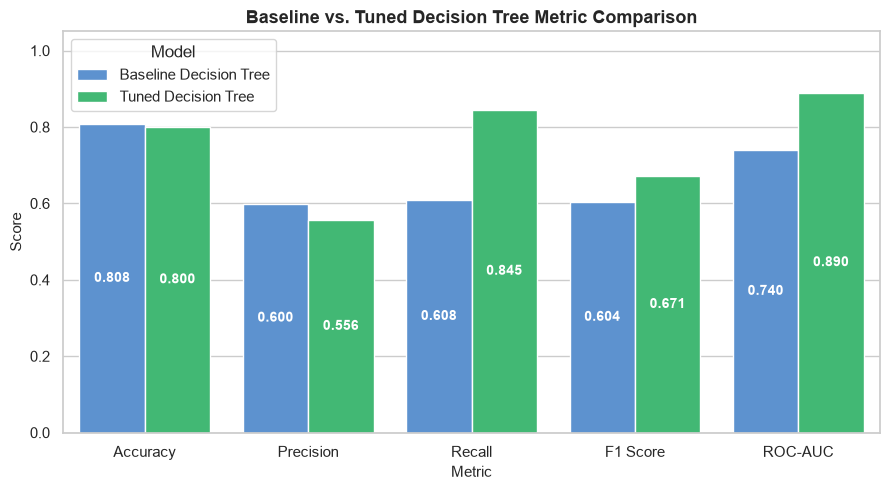

In [14]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline Decision Tree": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_roc_auc],
    "Tuned Decision Tree": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1, tuned_roc_auc]
})

comparison_display = comparison_df.copy()
comparison_display["Baseline Decision Tree"] = comparison_display["Baseline Decision Tree"].map("{:.4f}".format)
comparison_display["Tuned Decision Tree"] = comparison_display["Tuned Decision Tree"].map("{:.4f}".format)
comparison_display["Absolute Improvement"] = (comparison_df["Tuned Decision Tree"] - comparison_df["Baseline Decision Tree"]).map("{:+.4f}".format)

print("=======================================================================")
print("             BASELINE VS TUNED DECISION TREE COMPARISON                ")
print("=======================================================================")
display(comparison_display)

# Plot: Baseline vs Tuned Performance Comparison
plot_path = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_BaselineVsTuned.png"

df_melted = comparison_df.melt(id_vars=["Metric"], value_vars=["Baseline Decision Tree", "Tuned Decision Tree"],
                               var_name="Model", value_name="Score")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette=["#4a90e2", "#2ecc71"])
plt.title("Baseline vs. Tuned Decision Tree Metric Comparison", fontsize=13, fontweight="bold")
plt.ylim(0, 1.05)
plt.ylabel("Score")
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path.relative_to(PROJECT_ROOT))
plt.show()


### 15. Confusion Matrix Visualizations
Generate and export confusion matrix heatmaps for both baseline and tuned decision trees.


Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_Baseline_ConfusionMatrix.png


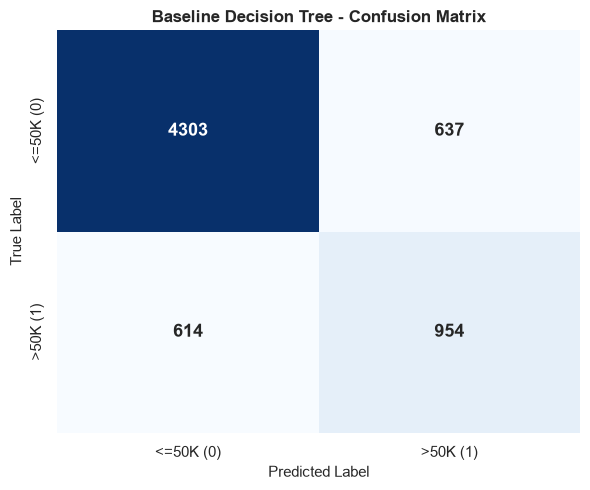

Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_Tuned_ConfusionMatrix.png


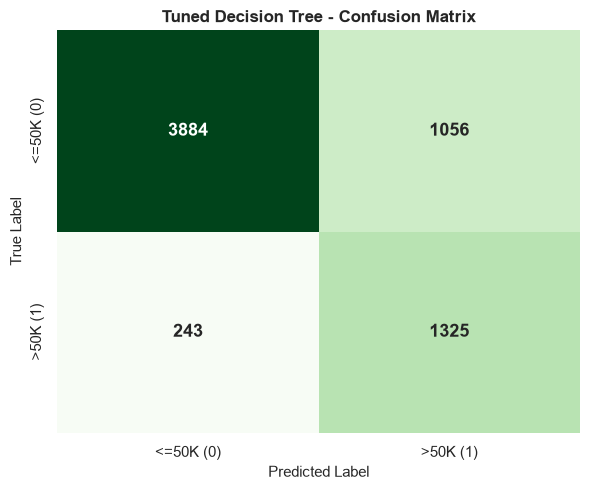

In [15]:
# 1. Baseline Confusion Matrix
cm_base = confusion_matrix(y_test, y_pred_base)
plot_path_base_cm = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_Baseline_ConfusionMatrix.png"

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_base, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['<=50K (0)', '>50K (1)'],
    yticklabels=['<=50K (0)', '>50K (1)'],
    annot_kws={'size': 13, 'fontweight': 'bold'}
)
plt.title('Baseline Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig(plot_path_base_cm, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path_base_cm.relative_to(PROJECT_ROOT))
plt.show()

# 2. Tuned Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plot_path_tuned_cm = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_Tuned_ConfusionMatrix.png"

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False,
    xticklabels=['<=50K (0)', '>50K (1)'],
    yticklabels=['<=50K (0)', '>50K (1)'],
    annot_kws={'size': 13, 'fontweight': 'bold'}
)
plt.title('Tuned Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig(plot_path_tuned_cm, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path_tuned_cm.relative_to(PROJECT_ROOT))
plt.show()


### 16. Receiver Operating Characteristic (ROC) Curve
Plot baseline vs. tuned ROC curves with AUC scores to demonstrate discriminatory gain across classification thresholds.


Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_ROC_Curve.png


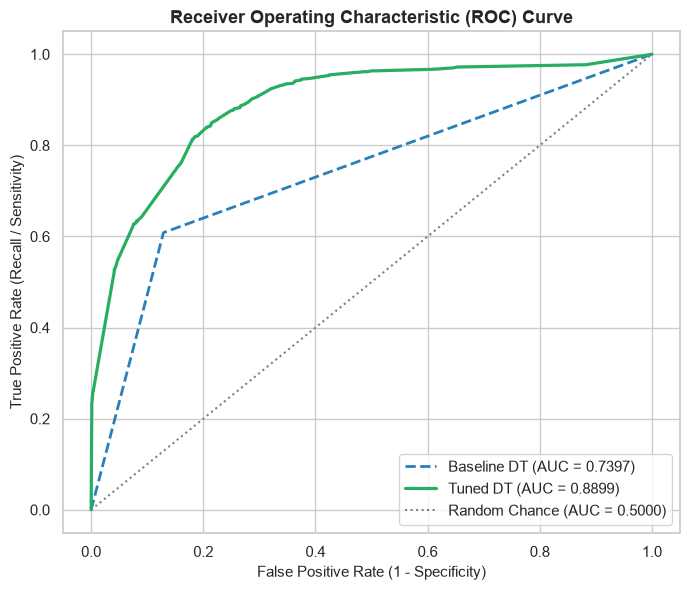

In [16]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)

plot_path_roc = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_ROC_Curve.png"

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, color='#2980b9', linestyle='--', linewidth=2, label=f'Baseline DT (AUC = {baseline_roc_auc:.4f})')
plt.plot(fpr_tuned, tpr_tuned, color='#27ae60', linewidth=2.3, label=f'Tuned DT (AUC = {tuned_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Chance (AUC = 0.5000)')

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(plot_path_roc, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path_roc.relative_to(PROJECT_ROOT))
plt.show()


### 17. Feature Importance Analysis
Extract transformed feature names and Gini importances from the tuned decision tree, ranking the top 15 most influential predictors.


--- Top 15 Most Important Features in Tuned Decision Tree ---


,Feature,Importance
0,cat__marital.status_Married-civ-spouse,0.488400
1,num__education.num,0.164913
2,num__capital.gain,0.149037
3,num__age,0.064219
4,num__capital.loss,0.039696
5,num__hours.per.week,0.039603
6,num__fnlwgt,0.017731
7,cat__occupation_Other-service,0.005461
8,cat__relationship_Wife,0.005033
9,cat__occupation_Exec-managerial,0.004216


Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_FeatureImportance.png


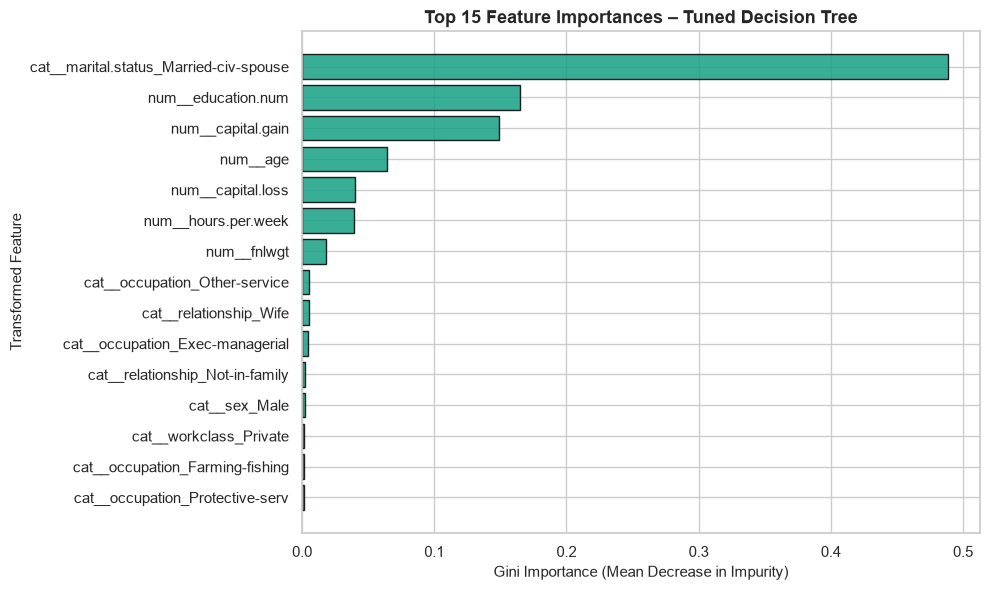

In [17]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("--- Top 15 Most Important Features in Tuned Decision Tree ---")
display(feature_importance_df.head(15))

# Plot Top 15 Feature Importances
plot_path_fi = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_FeatureImportance.png"

plt.figure(figsize=(10, 6))
top_15 = feature_importance_df.head(15).iloc[::-1]
plt.barh(top_15['Feature'], top_15['Importance'], color='#16a085', edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Importances – Tuned Decision Tree', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance (Mean Decrease in Impurity)', fontsize=11)
plt.ylabel('Transformed Feature', fontsize=11)
plt.tight_layout()
plt.savefig(plot_path_fi, dpi=300, bbox_inches="tight")
print("Saved plot:", plot_path_fi.relative_to(PROJECT_ROOT))
plt.show()


### 18. Decision Tree Structure Visualization
Render and export the pruned decision tree architecture (top 3 split levels) with feature split thresholds and class distributions.


Saved plot: results\eda_visualizations\models\IT25101220_DecisionTree_TreeStructure.png


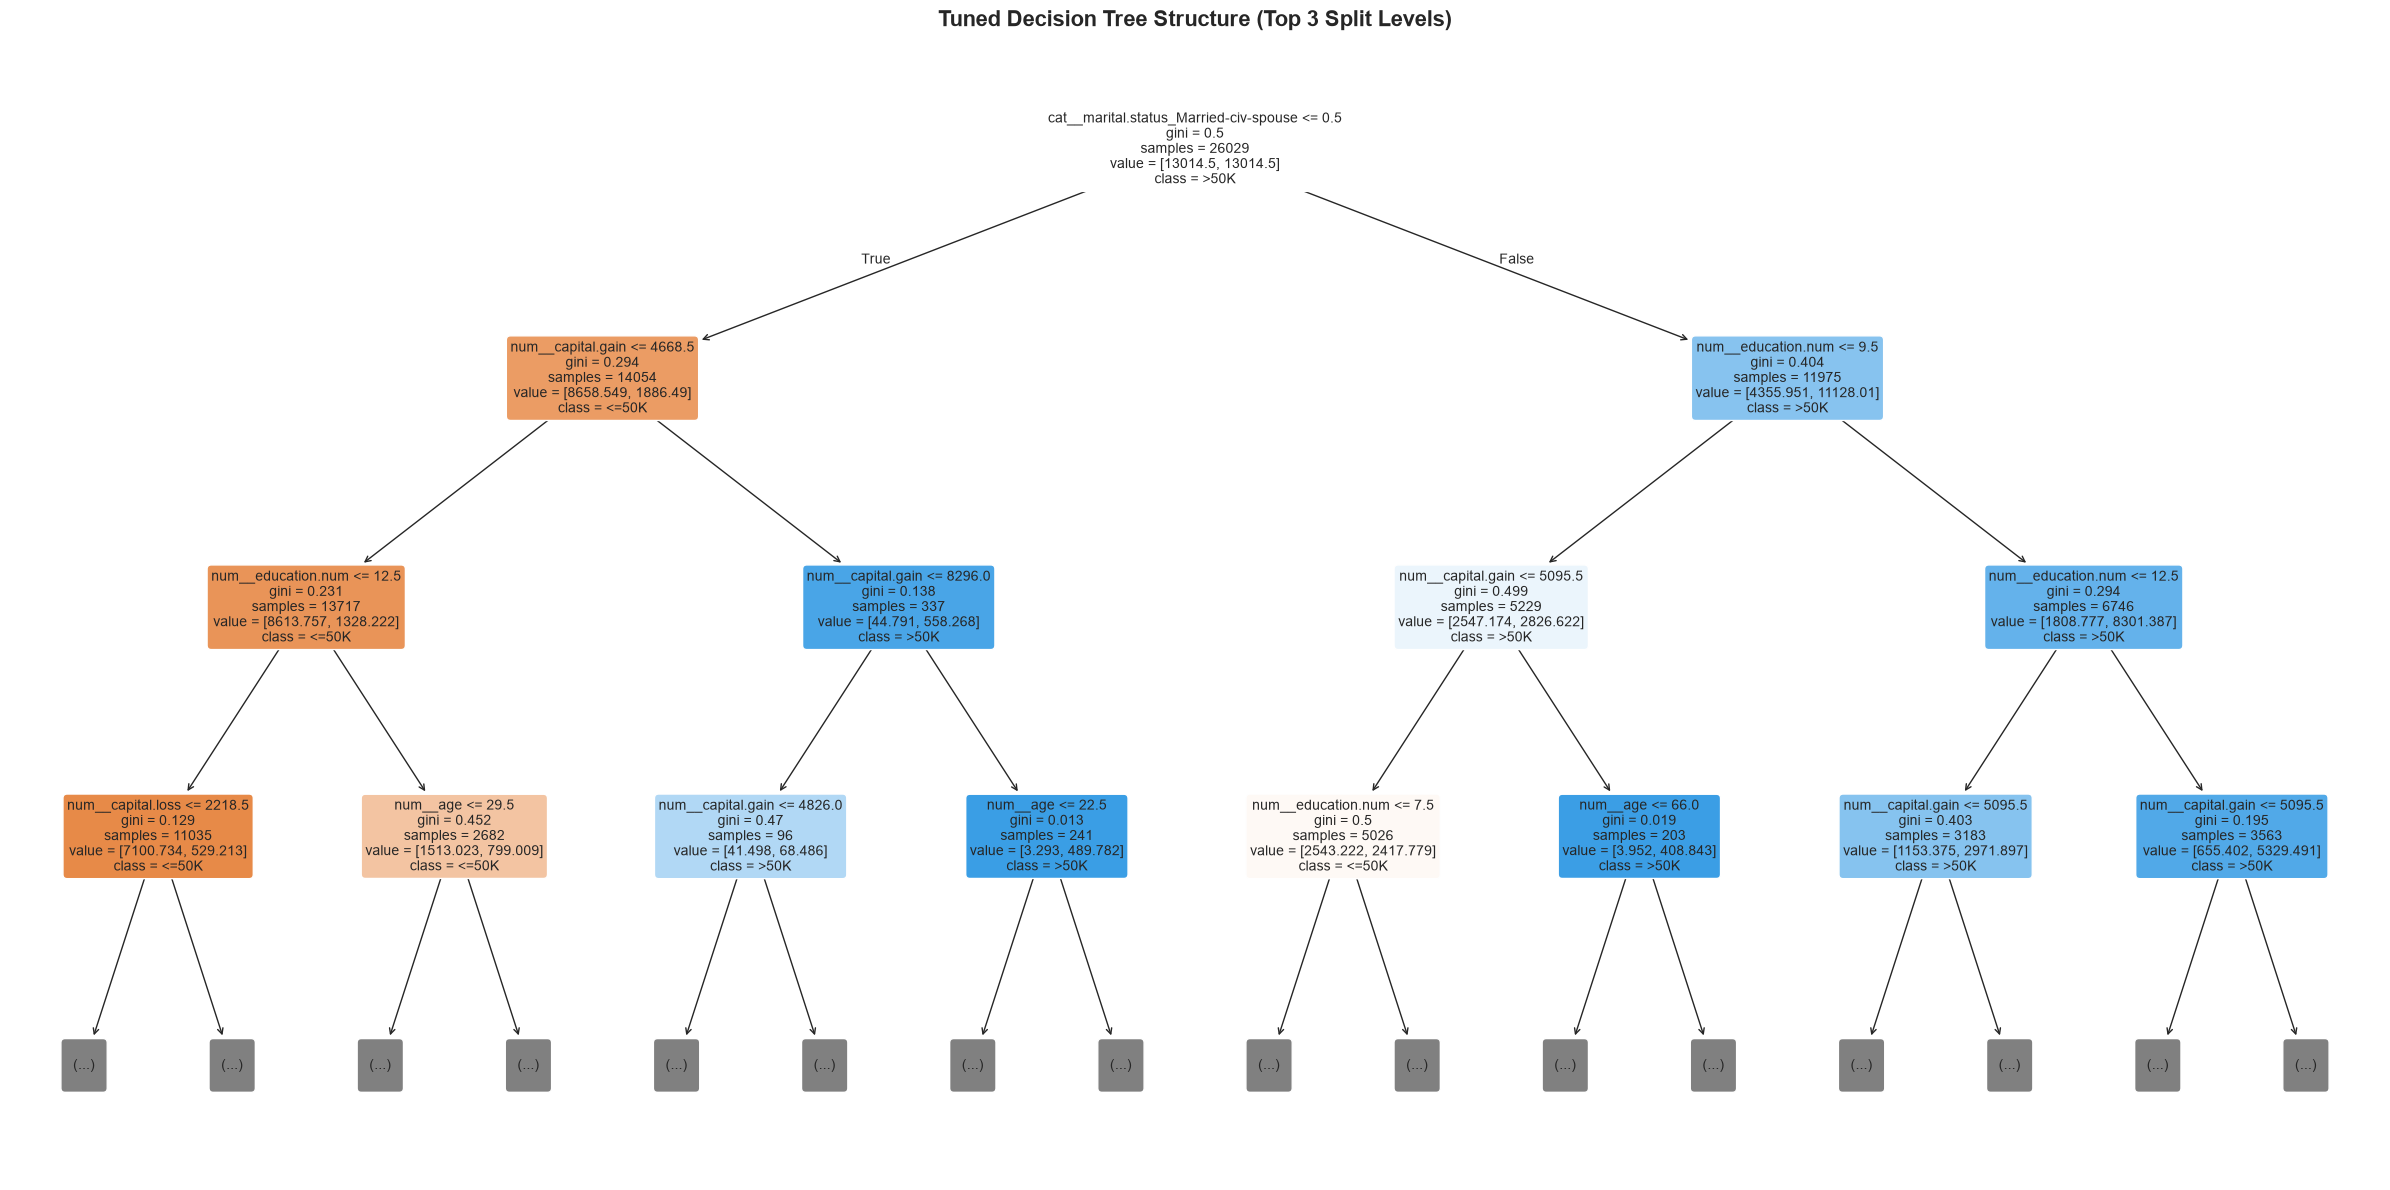

In [18]:
plot_path_tree = MODEL_PLOTS_DIR / "IT25101220_DecisionTree_TreeStructure.png"

plt.figure(figsize=(24, 12))
plot_tree(
    best_model.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)
plt.title('Tuned Decision Tree Structure (Top 3 Split Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(plot_path_tree, dpi=300, bbox_inches='tight')
print("Saved plot:", plot_path_tree.relative_to(PROJECT_ROOT))
plt.show()


### 19. Final Summary and JSON Export
Generate a consolidated summary table and programmatically serialize all model metrics, dataset details, and evaluation results into `results/model_results/IT25101220.json` for group comparison.


In [19]:
# 1. Consolidated Summary Table
summary_records = [
    ("Model Type", "DecisionTreeClassifier (Supervised Binary Classification)"),
    ("Target Variable", "income (0: <=50K, 1: >50K)"),
    ("Baseline Training Accuracy", f"{baseline_train_acc:.4f} ({baseline_train_acc * 100:.2f}%)"),
    ("Baseline Testing Accuracy", f"{baseline_test_acc:.4f} ({baseline_test_acc * 100:.2f}%)"),
    ("Baseline Generalization Gap", f"{baseline_gen_gap:.4f} ({baseline_gen_gap * 100:.2f}%)"),
    ("Baseline Accuracy", f"{baseline_accuracy:.4f}"),
    ("Baseline Precision", f"{baseline_precision:.4f}"),
    ("Baseline Recall", f"{baseline_recall:.4f}"),
    ("Baseline F1 Score", f"{baseline_f1:.4f}"),
    ("Baseline ROC-AUC", f"{baseline_roc_auc:.4f}"),
    ("5-Fold CV Mean F1 Score", f"{cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}"),
    ("Best Hyperparameters", str(grid_search.best_params_)),
    ("Best CV F1 Score", f"{best_cv_f1:.4f}"),
    ("Tuned Training Accuracy", f"{tuned_train_acc:.4f} ({tuned_train_acc * 100:.2f}%)"),
    ("Tuned Testing Accuracy", f"{tuned_test_acc:.4f} ({tuned_test_acc * 100:.2f}%)"),
    ("Tuned Generalization Gap", f"{tuned_gen_gap:.4f} ({tuned_gen_gap * 100:.2f}%)"),
    ("Tuned Accuracy", f"{tuned_accuracy:.4f}"),
    ("Tuned Precision", f"{tuned_precision:.4f}"),
    ("Tuned Recall", f"{tuned_recall:.4f}"),
    ("Tuned F1 Score", f"{tuned_f1:.4f}"),
    ("Tuned ROC-AUC", f"{tuned_roc_auc:.4f}"),
    ("Overfitting Observed & Cured?", f"YES (Baseline gap: {baseline_gen_gap * 100:.2f}% -> Tuned gap: {tuned_gen_gap * 100:.2f}%)"),
    ("Top Important Feature #1", f"{feature_importance_df.iloc[0]['Feature']} ({feature_importance_df.iloc[0]['Importance']:.4f})"),
    ("Top Important Feature #2", f"{feature_importance_df.iloc[1]['Feature']} ({feature_importance_df.iloc[1]['Importance']:.4f})"),
    ("Top Important Feature #3", f"{feature_importance_df.iloc[2]['Feature']} ({feature_importance_df.iloc[2]['Importance']:.4f})")
]

summary_table_df = pd.DataFrame(summary_records, columns=["Model Property / Metric", "Observed Value / Description"])

print("==========================================================================================")
print("                           DECISION TREE MODEL SUMMARY                                    ")
print("==========================================================================================")
display(summary_table_df)

# 2. Prepare the standardized Review 2 result required by src.common.save_member_result
best_params_clean = {k.replace("classifier__", ""): v for k, v in grid_search.best_params_.items()}
final_metrics = {
    "Accuracy": float(tuned_accuracy),
    "Balanced_Accuracy": float(balanced_accuracy_score(y_test, y_pred_tuned)),
    "Precision": float(tuned_precision),
    "Recall": float(tuned_recall),
    "F1_Score": float(tuned_f1),
    "ROC_AUC": float(tuned_roc_auc),
    "Train_Accuracy": float(tuned_train_acc),
    "Test_Accuracy": float(tuned_test_acc),
    "Generalization_Gap": float(tuned_gen_gap),
    "Best_CV_F1": float(best_cv_f1)
}

# Save through the shared group helper. Working directory is normalized to PROJECT_ROOT above.
save_member_result(
    "IT25101220",
    "DecisionTree",
    best_params_clean,
    final_metrics
)

json_output_path = MODEL_RESULTS_DIR / "IT25101220.json"
print("Saved standardized model result:", json_output_path.relative_to(PROJECT_ROOT))

with open(json_output_path, "r", encoding="utf-8") as f:
    loaded_json = json.load(f)
print("\n--- Standardized JSON Verification ---")
print(json.dumps(loaded_json, indent=2))


                           DECISION TREE MODEL SUMMARY                                    


,Model Property / Metric,Observed Value / Description
0,Model Type,DecisionTreeClassifier (Supervised Binary Clas...
1,Target Variable,"income (0: <=50K, 1: >50K)"
2,Baseline Training Accuracy,1.0000 (100.00%)
3,Baseline Testing Accuracy,0.8078 (80.78%)
4,Baseline Generalization Gap,0.1922 (19.22%)
5,Baseline Accuracy,0.8078
6,Baseline Precision,0.5996
7,Baseline Recall,0.6084
8,Baseline F1 Score,0.6040
9,Baseline ROC-AUC,0.7397


[+] Saved model result for IT25101220 (DecisionTree) to: results/model_results\IT25101220.json
Saved standardized model result: results\model_results\IT25101220.json

--- Standardized JSON Verification ---
{
  "it_number": "IT25101220",
  "model_name": "DecisionTree",
  "best_hyperparameters": {
    "class_weight": "balanced",
    "criterion": "gini",
    "max_depth": 10,
    "min_samples_leaf": 5,
    "min_samples_split": 20
  },
  "metrics": {
    "Accuracy": 0.8003995082974801,
    "Balanced_Accuracy": 0.8156301640089234,
    "Precision": 0.5564888702225955,
    "Recall": 0.8450255102040817,
    "F1_Score": 0.6710559635350721,
    "ROC_AUC": 0.8899394132653061,
    "Train_Accuracy": 0.8238119021091859,
    "Test_Accuracy": 0.8003995082974801,
    "Generalization_Gap": 0.02341239381170579,
    "Best_CV_F1": 0.6792667713673576
  }
}
